# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
nulos_users = users.isna().sum()
print(nulos_users)# Cantidad de valores nulos)
prop_nulos_users = (nulos_users.isnull().sum() / len(nulos_users)) * 100
print(prop_nulos_users)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
0.0


In [11]:
# cantidad de nulos para usage
nulos_usage = usage.isna().sum()
print(nulos_usage)# Cantidad de valores nulos)
prop_nulos_usage = (nulos_usage.isnull().sum() / len(nulos_usage)) * 100
print(prop_nulos_usage)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
0.0


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- #Para la columna de city en users, se propone solicitar información en cada ciudad para saber de acuerdo a las preferencias de usuario, si cuando dejan sus datos, prefieren NO informar su ciudad por cuestiones de seguridad o personales, es un volumen bajo por lo que tal vez el registro se hizo incompleto. Se propone llenar con NA en caso de que no se tenga que hacer un análisis geográfico extensivo crítico; esta acción funciona si lo que se pretende es entender los patrones de uso y comportamientos atípicos, ya que el análisis geográfico puede no aportar un valor crítico a esto.
- #Para la columna churn_date en users, se entiende que los usuarios están activos, por lo que los valores que queremos encontrar en esta columna precisamente son los que sí tienen datos, para esta columna se propone crear una columna adicional (1 si es nulo 0 si tiene fecha), en caso que se quiera analizar específicamente la información por separado de estos usuarios activos e inactivos.
- #Para las columnas duration y lenght hay que entender qué tipo de servicio es, si son llamadas significa que no conectaron, y si son mensajes se entiende que no tienen "duración", se propone generar una nueva columna con IF ELSE, donde si la actividad es mensaje, entonces se imputa 0.
- #Para la columna date, se propone verificar en el resto de las columnas si puede recuperarse esa fecha, al no ser muchos, podría llenarse con otro dato, como el día que más se repita
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
columnas_numericas_users = ['user_id','age']

print('Resumen estadístico users')
print(users[columnas_numericas_users].describe())
print('Usuarios únicos:',users['user_id'].nunique())
total_nulos_age = (users['age']== -999).sum()
print('Usuarios edad -999:',total_nulos_age)



Resumen estadístico users
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000
Usuarios únicos: 4000
Usuarios edad -999: 55


- La columna `user_id`
- #Agregué el código de unique para user_id, para estar segura que no hay usuarios repetidos, lo único valioso de esta columna en el análisis es saber este total, ya que al ser ids, no es relevante la información de media, mediana o los quartiles. Esta misma información la pude recibir del max-min (resultado sería 3999, más el número inicial), pero no está de más una doble confirmación
- La columna `age` ...
- #se cuentan con 55 registros donde el usuario no tiene la edad correcta, para este dato se contaron los registros donde la edad aparecía como "-999", se propone utilizar la media (33) o la mediana (47) para tener registros "válidos"

In [13]:
# explorar columnas numéricas de usage
columnas_numericas_usage = ['id','user_id','duration','length']

print('Resumen estadístico usage')
print(usage[columnas_numericas_usage].describe())

Resumen estadístico usage
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- #Para la columna id, se ve que el conteo es 40,000 registros, el mínimo es 1 y máximo es 40,000, esto nos indica la integridad de los datos, y no hay ninguno faltante. También, en caso de dudas, el 50% y el id son exactamente la mitad del total de los resultados, sin embargo como algo clave, a pesar que estas columnas son numéricas, no representan una estadística per sé, sino que son "etiquetas", así que la métrica de media o desviación estándar únicamente son datos relacionados a la cantidad de usuarios, y no hay fin adicional que pueda darse.
- #La columna duration tiene en conteo 17,924, lo que significa que más de la mitad de datos son nulos, la media es 5.2 por lo que probablemente se refiera a minutos, y la media 3.5 minutos igual, ya que la mediana es mayor que la media, sabemos que los datos están sesgados a la derecha en valores muy altos. El mínimo es 0, por lo que puede asumirse que son llamadas que no se conectaron, o llamadas perdidas. Y por último el 3er cuartil 6.9 y máximo es de 120, significa que hay usuarios con consumos atípicos extremos, con llamadas muy largas.
- #Por último, la columna length, presenta un volumen considerable, casi el 45% de los datos son nulos, sin embargo la media, la mediana se encuentran en un rango muy cercano, y el tercer percentil con 64 tampoco es una variación muy grande, sin embargo el máximo está totalmente alejado al comportamiento común con 1490, por lo que se recomienda investigar más a profundidad.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

print('Resumen categórico users')
print(users[columnas_user].describe())
print (' ')
print ('Distribución de planes')
print(users['plan'].value_counts(dropna=False))
print (' ')
print ('Distribución de ciudades')
print(users['city'].value_counts(dropna=False))

Resumen categórico users
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595
 
Distribución de planes
Basico     2595
Premium    1405
Name: plan, dtype: int64
 
Distribución de ciudades
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


- La columna `city` ...
- #En la columna city podemos notar 6 valores reales, unos ? que podría interpretarse como nulos ocultos, y NaN como nulos reales, de nuestro tal de 3531 registros, hay 565 que representan el 16% de los registros válidos que no tienen una ciudad realmente válida.
- La columna `plan` ...
- #Para la columna plan, se ven solamente 2 tipos de planes, el básico que es el más popular con el 64.87%, y el resto que contienen el plan premium. La integridad de los datos se ve completa, porque tiene un conteo total de 4000 valores, es decir, no tiene valores faltantes. 

In [15]:
# explorar columna categórica de usage

columnas_usage = ['type'] # completa el código

print('Resumen categórico usage')
print(usage[columnas_usage].describe())
print('  ')
print(usage['type'].value_counts(dropna=False))

Resumen categórico usage
         type
count   40000
unique      2
top      text
freq    22092
  
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` ...
- #En la columna type se puede notar nuevamente que la integridad de los datos está completa ya que el total de textos y llamadas llega a 40,000, y existen más de 4mil registros más de textos que de llamadas. Esto ya empieza a responder una de las preguntas de la empresa ConnectaTel sobre el patrón de uso


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? En usage se encontraron valores inválidos en las columnas duration y length, lo cual tiene sentido ya que no todos los registros son llamadas, y no todos los registros son textos. En users se encontraron valores nulos en age y en city.
- ¿Qué acción tomarías?
  #Para las diversas columnas donde se encontraron datos inválidos, se hicieron las propuestas por sección, básicamente lo que se propone es, dependiendo el tipo de dato se puedan imputar o eliminar algunos datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors="coerce") # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")# completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
print('Años presentes en users')
print(users['reg_date'].describe())
print('  ')
print('Años únicos en users')
print(users['reg_date'].nunique())
print('Cantidades por año')
print(users['reg_date'].dt.year.value_counts())

Años presentes en users
count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object
  
Años únicos en users
3961
Cantidades por año
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


#En `reg_date` de 4000 datos, hay 3961 que son únicos, significa que existen 39 que están duplicados, lo cual no necesariamente es algo incorrecto porque es posible que se haya hecho la llamada o texto en diferentes lugares o simplemente por diferentes usuarios. Adicional y más importante, si estos registros son de 2024, y existen 40 fechas que están en 2026, significa que son datos erróneos, lo que se proponen es que se imputen por la media o por la moda. ... haz doble clic en este bloque y escribe qué ves.

In [19]:
# Revisar los años presentes en `date` de usage
print('Años presentes en usage')
print(usage['date'].describe())
print('  ')
print('Años únicos en usage')
print(usage['date'].nunique())

Años presentes en usage
count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object
  
Años únicos en usage
39950


En `date` se puede observar que todos los datos son únicos, no hay ningún repetido, y se confirma la integridad de los datos con que la frecuencia es la misma de 1 para todos ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) - ¿Qué harías con ellas?:
#Para usage todos los datos se encuentran en 2024, sin embargo para users existen registros con el año 2026. Al día de hoy no es un dato "imposible", sin embargo se debería tomar en consideración si es real que no existen nuevos usuarios desde 2024 para acá, o si se debe revisar la calidad de la información para descartar errores en los registros.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
print(f"La mediana calculada fue: {age_mediana}")
users['age'].describe()

La mediana calculada fue: 47.0


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(f"Ciudad actualizada")
users['city'].describe()

Ciudad actualizada


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
año_incorrecto = users['reg_date'].dt.year == 2026
users.loc[año_incorrecto,'reg_date']= pd.NaT

# Verificar cambios
print(f"Fecha futura de registro 2026 eliminada")
users['reg_date'].describe()

Fecha futura de registro 2026 eliminada


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print("--- Nulos en Duration por Tipo ---")
print(pd.crosstab(usage['type'], usage['duration'].isna(), rownames=['Tipo'], colnames=['¿Es Nulo?']))

--- Nulos en Duration por Tipo ---
¿Es Nulo?  False  True 
Tipo                   
call       17908      0
text          16  22076


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print("\n--- Nulos en Length por Tipo ---")
print(pd.crosstab(usage['type'], usage['length'].isna(), rownames=['Tipo'], colnames=['¿Es Nulo?']))


--- Nulos en Length por Tipo ---
¿Es Nulo?  False  True 
Tipo                   
call          12  17896
text       22092      0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
#Existe una correlación casi absoluta entre el tipo de servicio y la ausencia de datos. En "Duration" el 99.9% de los mensajes "text" presentan un valor nulo de los 22,076 registros. De igual manera en "Lenght" las llamadas presentan un valor nulo. Lo cual indica que ni las llamadas tienen caracteres de texto, ni los mensajes tienen acumulación de segundos. Sin embargo existen valores atípicos, hay 16 mensajes con duración registrada, y 12 llamadas con texto. 
#Para la limpieza de datos se sugiere imputar con "0" los valores nulos estructurales, de esta manera se mantienen los registros del volumen principal.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
columnas_nuevas = {
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
}
usage_agg.rename(columns=columnas_nuevas, inplace=True)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
col_numericas = ['user_id','age','cant_mensajes','cant_llamadas','cant_minutos_llamada']

print(f"Resumen estadístico de columnas numéricas")
print(user_profile[col_numericas].describe())


Resumen estadístico de columnas numéricas
            user_id          age  cant_mensajes  cant_llamadas  \
count   4000.000000  4000.000000    3999.000000    3999.000000   
mean   11999.500000    48.122250       5.524381       4.478120   
std     1154.844867    17.690408       2.358416       2.144238   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.750000    33.000000       4.000000       3.000000   
50%    11999.500000    47.000000       5.000000       4.000000   
75%    12999.250000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              23.317054  
std               18.168095  
min                0.000000  
25%               11.120000  
50%               19.780000  
75%               31.415000  
max              155.690000  


In [29]:
# Distribución porcentual del tipo de plan
print("Frecuencia absoluta del tipo de plan")
print(user_profile['plan'].value_counts())
print("  ")
print("Frecuencia relativa del tipo de plan")
print(user_profile['plan'].value_counts(normalize=True))

Frecuencia absoluta del tipo de plan
Basico     2595
Premium    1405
Name: plan, dtype: int64
  
Frecuencia relativa del tipo de plan
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

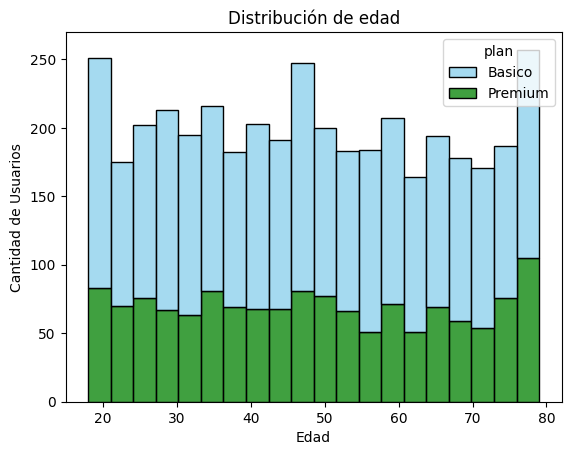

In [30]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', bins=20, hue='plan', multiple='stack', palette=['skyblue','green'])
plt.title('Distribución de edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


💡Insights: 
1. **Distribución General:** En la distribución de las edades de los clientes, la proporción entre usuarios del Plan Básico y el Plan Premium se mantiene estable. Se entiende que la edad biológica no es el factor fundamental para la elección de un plan premium; el comportamiento de compra está estandarizado en la población adulta.
2. **Estabilidad del Segmento Premium:** La base de usuarios Premium muestra un comportamiento estable en casi todos los rangos de edad, lo que confirma que este servicio cuenta con un valor percibido constante que no se degrada con la madurez del usuario.
3. **Anomalía en el Extremo Superior (Adultos Mayores):** Se observa un incremento atípico en el volumen total de usuarios (y un pico visible en el Plan Premium) en el rango de los 75 a 80 años.

**Detalles de uso:** Se utilizaron 15 bins para asegurar el entendimiento de la tabla.

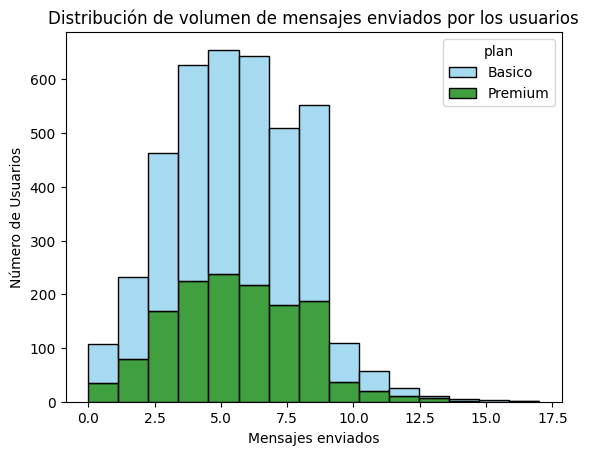

In [31]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', bins=15, hue='plan', multiple='stack', palette=['skyblue','green'])
plt.title('Distribución de volumen de mensajes enviados por los usuarios')
plt.xlabel('Mensajes enviados')
plt.ylabel('Número de Usuarios')

plt.show()




💡Insights: 
1. **Distribución General:** En la distribución de la cantidad de mensajes, se aprecia que existe estabilidad en la cantidad de mensajes enviados tanto en el plan Básico como en el Premium. El plan Básico mantiene la mayor cantidad de usuarios en todos los niveles de consumo, y la curva se ve reflejada en los usuarios Premium. Esto nos indica que los usuarios que compraron el plan Premium no necesariamente compraron este plan por el volumen de mensajes que necesitaban o deseaban mandar.
2. **Asimetría Positiva:** La gráfica muestra un notable sesgo hacia la derecha, lo cual muestra que la gran mayoría de los usuarios son de consumo moderado y se concentran firmemente entre 2.5 y 10 mensajes. 
3. **Estrategia de Producto:** El patrón de envío de mensajes es casi idéntico en ambos planes, lo cual demuestra que los SMS ya no son un factor de diferenciación de valor agregado para la venta de los planes, lo cual puede concentrar el valor del servicio en otros beneficios.

**Detalles de uso:** Se utilizaron 15 bins para asegurar el entendimiento de la tabla.


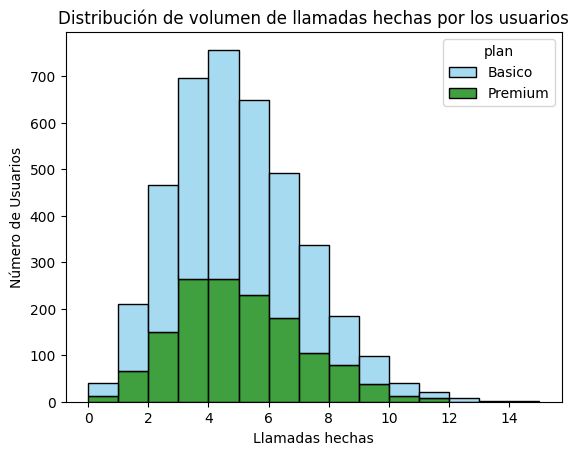

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', bins=15, hue='plan', multiple='stack', palette=['skyblue','green'])
plt.title('Distribución de volumen de llamadas hechas por los usuarios')
plt.xlabel('Llamadas hechas')
plt.ylabel('Número de Usuarios')

plt.show()



💡Insights: 

1. **Forma de la gráfica (Distribución Normal):** A diferencia de la gráfica de los mensajes, aquí vemos que los datos forman una especie de "campana", similar a la campana de Gauss. Esto indica que la mayoría de los usuarios no se desvían ni a muy pocas, ni a demasiadas llamadas, sino que se concentran en un término medio, principalmente entre 3 y 7 llamadas por persona.
2. **Comparación entre planes:** Aunque hay más usuarios con el Plan Básico en toda la gráfica, se nota que en el lado derecho (las personas que hacen más de 8 llamadas) las barras verdes del Plan Premium se ven más grandes o estables en proporción. Esto nos dice que los usuarios que necesitan hablar más por teléfono tienden a elegir el plan Premium.
3. **Conexión con el negocio:** Este comportamiento demuestra que las llamadas y los minutos siguen siendo importantes para los usuarios que pagan el plan más caro. A diferencia de los mensajes de texto, la cantidad de llamadas sí es un factor que ayuda a diferenciar el comportamiento entre un usuario de plan Básico y uno Premium.

**Detalles de uso:** Se utilizaron 15 bins para asegurar el entendimiento de la tabla.

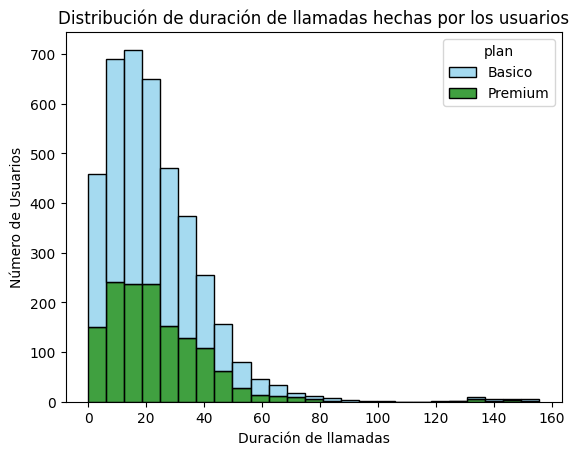

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=25, hue='plan', multiple='stack', palette=['skyblue','green'])
plt.title('Distribución de duración de llamadas hechas por los usuarios')
plt.xlabel('Duración de llamadas')
plt.ylabel('Número de Usuarios')

plt.show()


💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

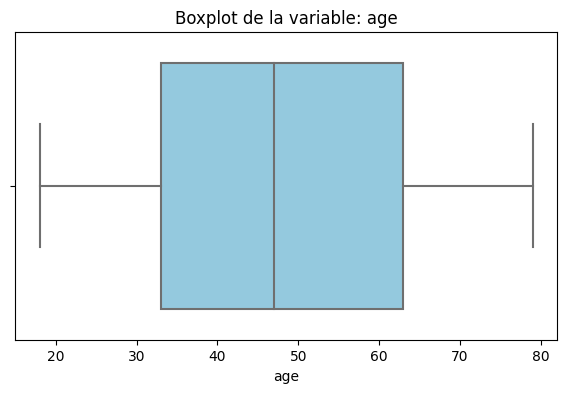

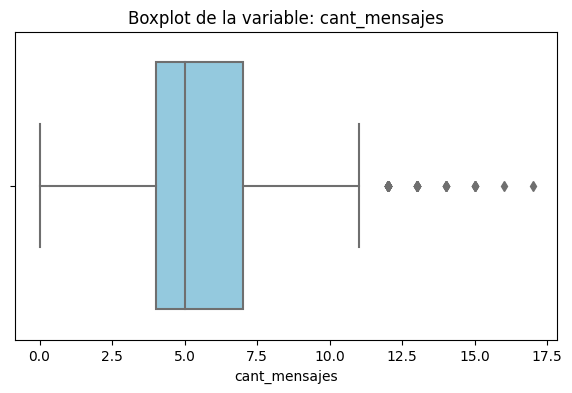

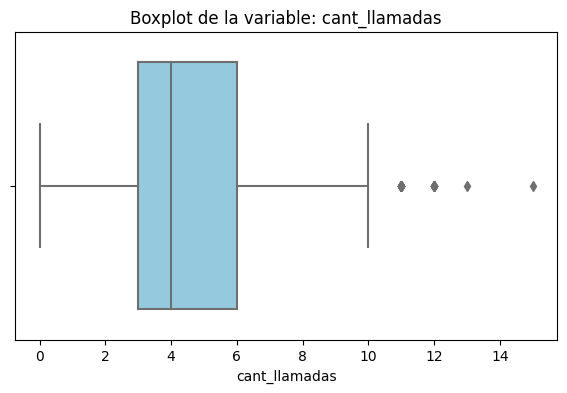

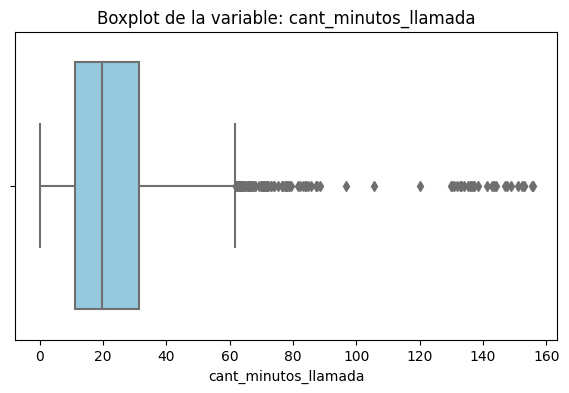

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:    
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot de la variable: {col}')
    plt.xlabel(col)
plt.show()


💡Insights: 
- Age: No presenta outliers hacia los extremos. Esto nos indica que los datos son limpios y acotados y no se encuentran fuera del rango lógico que se espera de las edades de los usuarios.
- cant_mensajes: Sí se presentan outliers que representan usuarios de alto consumo de mensajería. Se puede hacer una oferta personalizada a los usuarios del plan básico para que migren al plan premium con el argumento comercial de que el plan superior puede adaptarse mejor a sus necesidades. Por otro lado si los usuarios ya se encuentran en el plan premium puede hacerse una revisión de sus beneficios, ya que son clientes más "activos" y valiosos para la compañía, lo cual genera mayor satisfacción de cliente porque podrían sentirse "atendidos"
- cant_llamadas: Esta gráfica mantiene un patrón similar al sistema de mensajería, por lo que el análisis y la propuesta pueden compartirse en ambos
- cant_minutos_llamada: Esta variable es la que más valores atípicos presenta dispersos hacia la derecha, lo que significa que una cantidad significativa de usuarios acumulan consumo más alto en tiempo en llamada, por lo cual la propuesta de valor para estos usuarios debe ajustarse a sus necesidades también, aunque actualmente ya existe en México la ley de telecomunicaciones que ha hecho que los servicios de llamadas y mensajería ofrezcan "minutos ilimitados", puede extenderse a otros países si es que aún no se ha hecho. También puede ofrecerse a los usuarios del plan premium la garantía de mayor estabilidad y calidad de voz en las llamadas de larga duración, y por último a los usuarios del plan básico que también se presenten en el plan básico, se les puede ofertar el plan premium con esos mismos beneficios.

In [35]:
# Calcular límites con el método IQR
resultados = {}
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1
    lim_inferior = Q1 - 1.5 * IQR
    lim_superior = Q3 + 1.5 * IQR
    outliers_detectados = user_profile[user_profile[col] > lim_superior].shape[0]
    resultados[col] = outliers_detectados

print("Diccionario final de resultados:")
print(resultados)

Diccionario final de resultados:
{'cant_mensajes': 46, 'cant_llamadas': 30, 'cant_minutos_llamada': 109}


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener: El consumo representado en el outlier no es significativo como para eliminar el resultado, no hay indicio de un error en el proceso, y es un proceso real y posible para un usuario activo.
- cant_llamadas: mantener o no outliers, porqué? Mantener: El consumo representado en el outlier no es significativo como para eliminar el resultado, no hay indicio de un error en el proceso, y es un proceso real y posible para un usuario activo.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener: A pesar que el máximo (155.69) esté alejado del Q3 (31.415), las llamadas largas en la industria de telecomunicaciones son esenciales para algunos tipos de usuarios de manera continua, y también de manera esporádica para todos los usuarios (llamadas comerciales, familiares, o de soporte de algún negocio como un banco), eliminar estos resultados sesgaría el análisis y podría significar pérdida de datos valiosos para propuestas futuras.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), # Bajo uso de llamadas y mensajes
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) # Uso medio de llamadas y mensajes
]
etiquetas = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(condiciones, etiquetas, default='Alto uso')
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
condiciones_edad = [
    (user_profile['age'] < 30), # Menores de 30 años
    (user_profile['age'] < 60) # Entre 30 y 59 años
]
etiquetas_edad = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(condiciones_edad, etiquetas_edad, default='Adulto Mayor')

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

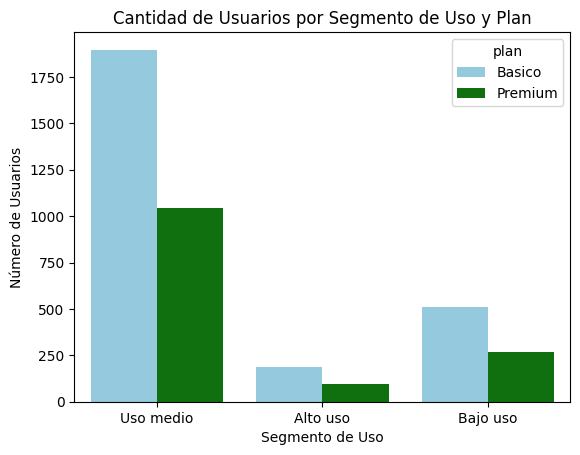

In [42]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', hue='plan', palette=['skyblue', 'green'])
plt.title('Cantidad de Usuarios por Segmento de Uso y Plan')
plt.xlabel('Segmento de Uso')
plt.ylabel('Número de Usuarios')
plt.show()


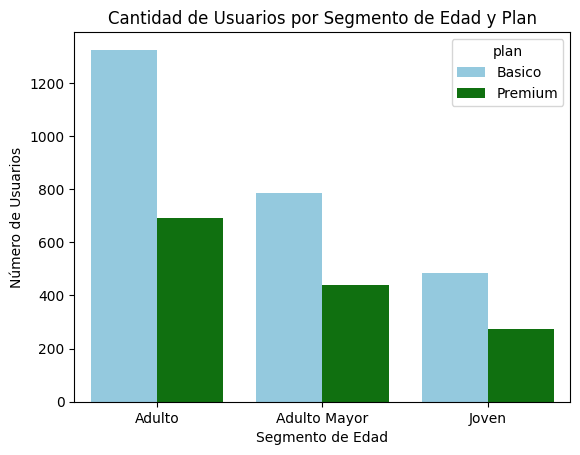

In [46]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', hue='plan', palette=['skyblue', 'green'])
plt.title('Cantidad de Usuarios por Segmento de Edad y Plan')
plt.xlabel('Segmento de Edad')
plt.ylabel('Número de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?



✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectó presencia de valores faltantes en la variable age. Para corregir esta variación sin perder la información, se imputó con la mediana de la edad del resto de la base de usuarios
- En la variable city también se encontraron datos faltantes que, al no tener la certeza de cual ciudad vienen dichos usuarios, se imputó el dato faltan con "NA" válido para Python y evitar mezcla de objetos, de esta manera se pueden analizar los datos sin tanta variabilidad.
- Para las columnas de duration y length, se hizo una limpieza para evitar que las llamadas tuvieran longitud, y los mensajes tuvieran duración.
- También se hizo la estandarización de las fechas de registro para tener datos similares (es decir, no comparar peras con manzanas).

🔍 **Segmentos por Edad**
- #Se segmentaron los clientes basados en criterios demográficos de edad. Dichos segmentos son: Jóvenes menores de 30 años, Adulto de 30 a 60 años, y Adulto mayor de 61. 

📊 **Segmentos por Nivel de Uso**
- Los criterios de uso se segmentaron en 3 categorías, las cuales fueron Bajo uso con llamadas y mensajes menores a 5, Uso medio con llamadas y mensajes entre 5 y 10, y Alto uso para los que superaban estas cantidades.


➡️ Esto sugiere que ...
- Los "High Value Customers" son aquellos que se encuentran utilizando el plan Premium y hacen un uso alto del mismo, lo cual nos indica que estos clientes generen un consumo constante en llamadas de larga duración, y confirman la hipótesis que esas llamadas son la principal fuente de retención de las ofertas Premium, se justifica la tarifa superior del plan porque están dispuestos a pagarla.
- Adicional, el análisis estadístico intercuartílico sesgado a la derecha en las variables de consumo, sobre todo en los minutos por llamada, indican una clara dirección hacia la mejora continua respecto a la infraestructura de la red, esto significa que mientras mejor sea la infraestructura, los clientes potencialmente estarán más contentos con el servicio, y si se les brinda "beneficios adicionales" por ser clientes premium (como la red de internet, ej: internet para redes sociales, o para redes de comunicación para trabajo), es seguro que su satisfacción aumentará más.

💡 **Recomendaciones**
-Como se mencionó en los puntos anteriores, mejorar la propuesta de valor del servicio brindado por ConnectaTel puede justificar la diferencia en el paquete Premium comparado al paquete básico.
- También se propone una campaña de migración focalizada en los usuarios de alto consumo hacia el paquete Premium, donde se explique los beneficios del cambio de plan y cómo este nuevo paquete les ayudaría en sus actividades que ya realizan (llamadas de larga duración).
- Por último se sugiere una segmentación del plan premium, donde el foco sean los adultos mayores que difícilmente explotarán al máximo el uso de los mensajes SNS, y la propuesta de "mejora" focalizada en ellos sería una mejor calidad de audio en las llamadas, y una mejor red para que puedan comunicarse donde sea que se encuentren. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`